In [ ]:
!pip -q install evaluate rouge-score sacrebleu datasets transformers accelerate


In [ ]:
import os, random, re
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from datasets import Dataset

from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments, Seq2SeqTrainer
)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
print("CUDA:", torch.cuda.is_available())


CUDA: True


In [ ]:
df = pd.read_excel("/content/HeadlinesStylesDataSet .xlsx")

df = df.rename(columns={
    "article_text": "article",
    "Analytical_Headline": "gold_analytical",
    "Breaking_Headline": "gold_breaking",
    "Simple_Headline": "gold_simple",
    "original_headline": "gold_original",
})

df = df[["article","gold_analytical","gold_breaking","gold_simple","gold_original"]].dropna().reset_index(drop=True)

print("Rows:", len(df))
print("Cols:", df.columns.tolist())

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)
val_df, test_df   = train_test_split(temp_df, test_size=0.5, random_state=42, shuffle=True)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))


Rows: 3225
Cols: ['article', 'gold_analytical', 'gold_breaking', 'gold_simple', 'gold_original']
Train: 2580 Val: 322 Test: 323


In [ ]:
PROMPT_V2 = (
"Generate 3 Arabic headlines based strictly on the FACTS in the article.\n"
"Rules:\n"
"1) Do NOT invent information.\n"
"2) Use specific entities/numbers if present.\n"
"3) Breaking must start with 'عاجل:'.\n"
"Return exactly:\n"
"FACTS: ...\nANALYTICAL: ...\nBREAKING: ...\nSIMPLE: ...\n\n"
"ARTICLE:\n"
)

def normalize_ar(text):
    text = str(text)
    text = re.sub(r"[إأآا]", "ا", text)
    text = re.sub(r"ى", "ي", text)
    text = re.sub(r"[\u064B-\u0652]", "", text)
    text = re.sub(r"ـ", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def make_facts(row, n_words=12):

    words = normalize_ar(row["gold_simple"]).split()
    return " ".join(words[:n_words])

def build_target_v2(row):
    facts = make_facts(row, n_words=12)
    return (
        f"FACTS: {facts}\n"
        f"ANALYTICAL: {row['gold_analytical']}\n"
        f"BREAKING: {row['gold_breaking']}\n"
        f"SIMPLE: {row['gold_simple']}"
    )

def prepare_df_v2(df_):
    df_ = df_.copy()
    df_["source"] = PROMPT_V2 + df_["article"].astype(str)
    df_["target"] = df_.apply(build_target_v2, axis=1)
    return df_[["source","target","article","gold_analytical","gold_breaking","gold_simple","gold_original"]]

train_prepared = prepare_df_v2(train_df)
val_prepared   = prepare_df_v2(val_df)
test_prepared  = prepare_df_v2(test_df)

print("--- TARGET SAMPLE ---")
print(train_prepared.loc[0,"target"])


--- TARGET SAMPLE ---
FACTS: اعتقال اسرائيلي بامريكا بشبهة اعتداءات
ANALYTICAL: اعتقال إسرائيلي بسبب شبهات اعتداءات بسلاح أبيض في الولايات المتحدة
BREAKING: عاجل: اعتقال إسرائيلي بأمريكا بشبهة اعتداءات بسلاح أبيض
SIMPLE: اعتقال إسرائيلي بأمريكا بشبهة اعتداءات


#arabart

In [ ]:
train_ds = Dataset.from_pandas(train_prepared)
val_ds   = Dataset.from_pandas(val_prepared)
test_ds  = Dataset.from_pandas(test_prepared)

model_name = "moussaKam/AraBART"
tokenizer = AutoTokenizer.from_pretrained(model_name)


model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

print("Loaded:", model_name)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loaded: moussaKam/AraBART


In [ ]:
max_source_len = 512
max_target_len = 96

def tokenize_fn(batch):
    inputs = tokenizer(batch["source"], max_length=max_source_len, truncation=True)
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(batch["target"], max_length=max_target_len, truncation=True)
    inputs["labels"] = labels["input_ids"]
    return inputs

train_tok = train_ds.map(tokenize_fn, batched=True, remove_columns=train_ds.column_names)
val_tok   = val_ds.map(tokenize_fn, batched=True, remove_columns=val_ds.column_names)
test_tok  = test_ds.map(tokenize_fn, batched=True, remove_columns=test_ds.column_names)

data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)
print("Tokenization done.")


Map:   0%|          | 0/2580 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4169: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/322 [00:00<?, ? examples/s]

Map:   0%|          | 0/323 [00:00<?, ? examples/s]

Tokenization done.


In [ ]:
import evaluate

rouge = evaluate.load("rouge")
bleu  = evaluate.load("sacrebleu")

def compute_metrics(eval_preds):
    preds, labels = eval_preds

    if isinstance(preds, tuple):
        preds = preds[0]


    if hasattr(preds, "ndim") and preds.ndim == 3:
        preds = np.argmax(preds, axis=-1)

    preds = np.array(preds, dtype=np.int64)
    preds = np.where(preds < 0, tokenizer.pad_token_id, preds)

    labels = np.array(labels, dtype=np.int64)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    decoded_preds  = tokenizer.batch_decode(preds, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds  = [normalize_ar(p) for p in decoded_preds]
    decoded_labels = [normalize_ar(l) for l in decoded_labels]

    rouge_scores = rouge.compute(predictions=decoded_preds, references=decoded_labels)
    bleu_score   = bleu.compute(predictions=decoded_preds, references=[[x] for x in decoded_labels])

    return {
        "rouge1": rouge_scores["rouge1"],
        "rouge2": rouge_scores["rouge2"],
        "rougeL": rouge_scores["rougeL"],
        "bleu": bleu_score["score"],
    }

print("Metrics ready.")


Metrics ready.


In [ ]:
out_dir = "./checkpoints/arabart_v2_clean"

training_args = Seq2SeqTrainingArguments(
    output_dir=out_dir,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_strategy="steps",
    logging_steps=50,

    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,

    learning_rate=5e-5,
    num_train_epochs=5,
    warmup_ratio=0.1,
    weight_decay=0.01,

    label_smoothing_factor=0.1,

    predict_with_generate=True,
    generation_max_length=max_target_len,
    generation_num_beams=4,

    load_best_model_at_end=True,
    metric_for_best_model="rougeL",
    greater_is_better=True,

    fp16=torch.cuda.is_available(),
    report_to="none",
    save_total_limit=2,
)


In [ ]:
import transformers
print(transformers.__version__)


4.57.3


In [ ]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()


/tmp/ipython-input-2465694899.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Bleu
1,2.933800,2.692491,0.883104,0.776998,0.882239,16.139552
2,2.619600,2.518248,0.937137,0.860693,0.936359,16.721729
3,2.460000,2.454620,0.932393,0.846067,0.931922,17.886273
4,2.397300,2.426848,0.951075,0.870802,0.950450,17.872446
5,2.352200,2.420475,0.951490,0.877497,0.950663,17.861613


/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'early_stopping': True, 'num_beams': 4, 'no_repeat_ngram_size': 3}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(
There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


TrainOutput(global_step=810, training_loss=2.71508767163312, metrics={'train_runtime': 1491.0558, 'train_samples_per_second': 8.652, 'train_steps_per_second': 0.543, 'total_flos': 3188866759778304.0, 'train_loss': 2.71508767163312, 'epoch': 5.0})

In [ ]:
test_metrics = trainer.evaluate(test_tok, metric_key_prefix="test")
print(test_metrics)


{'test_loss': 2.4288792610168457, 'test_rouge1': 0.9638240328642805, 'test_rouge2': 0.9059414184027191, 'test_rougeL': 0.9630483207882592, 'test_bleu': 17.549841360408685, 'test_runtime': 145.2813, 'test_samples_per_second': 2.223, 'test_steps_per_second': 1.115, 'epoch': 5.0}


In [ ]:
def parse_generated(text):
    out = {"facts":"","analytical":"","breaking":"","simple":""}
    lines = [l.strip() for l in str(text).split("\n") if l.strip()]
    for l in lines:
        u = l.upper()
        if u.startswith("FACTS:"):
            out["facts"] = l.split(":",1)[1].strip()
        elif u.startswith("ANALYTICAL:"):
            out["analytical"] = l.split(":",1)[1].strip()
        elif u.startswith("BREAKING:"):
            out["breaking"] = l.split(":",1)[1].strip()
        elif u.startswith("SIMPLE:"):
            out["simple"] = l.split(":",1)[1].strip()
    return out

def generate_one(article_text):
    prompt = PROMPT_V2 + str(article_text)
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=max_source_len).to(model.device)

    gen_ids = model.generate(
        **inputs,
        max_new_tokens=max_target_len,
        num_beams=4,
        do_sample=False,
        repetition_penalty=1.3,
        no_repeat_ngram_size=4,
        length_penalty=0.9,
        early_stopping=True
    )
    return tokenizer.decode(gen_ids[0], skip_special_tokens=True)

for i in range(5):
    print("="*60)
    pred = generate_one(test_df.loc[i,"article"])
    print("PRED:\n", pred)
    print("\nPARSED:\n", parse_generated(pred))
    print("\nGOLD:\n", test_prepared.loc[i,"target"])


PRED:
 FACTS: كيري يلتقي وزير الدفاع المصري ANALYTICAL: كيري يلتقي بوزير الدفاع المصري يدفع إلى تداعيات مباشرة وتغيرات قريبة BREAKING: عاجل: كيري يلتقي ووزير الدفاع المصري في واشنطن SIMPLE: كيري يلتقي لوزير الدفاع المصري

PARSED:
 {'facts': 'كيري يلتقي وزير الدفاع المصري ANALYTICAL: كيري يلتقي بوزير الدفاع المصري يدفع إلى تداعيات مباشرة وتغيرات قريبة BREAKING: عاجل: كيري يلتقي ووزير الدفاع المصري في واشنطن SIMPLE: كيري يلتقي لوزير الدفاع المصري', 'analytical': '', 'breaking': '', 'simple': ''}

GOLD:
 FACTS: كيري يحض الحكومة المصرية علي الحوار مع المعارضة
ANALYTICAL: كيري يحض الحكومة المصرية على الحوار مع المعارضة يدفع إلى تداعيات مباشرة وتغيرات قريبة
BREAKING: عاجل: كيري يحض الحكومة المصرية على الحوار مع المعارضة
SIMPLE: كيري يحض الحكومة المصرية على الحوار مع المعارضة
PRED:
 FACTS: اشتباكات عنيفة في شمال كردفان ANALYTICAL: اشتباكات عنيفة يدفع إلى اشتباكات عنيفة في ويغير المشهد BREAKING: عاجل: اشتباكات عنيفة بين متمردين شمالي كردفان SIMPLE: اشتباكات عنيفة فى شمال كردفان

PARSED:
 {'fac

In [ ]:
for i in range(5):
    print("="*60)
    pred = generate_one(test_df.loc[i,"article"])
    print("PRED:\n", pred)
    print("\nGOLD:\n", test_prepared.loc[i,"target"])


PRED:
 FACTS: كيري يلتقي وزير الدفاع المصري ANALYTICAL: كيري يلتقي بوزير الدفاع المصري يدفع إلى تداعيات مباشرة وتغيرات قريبة BREAKING: عاجل: كيري يلتقي ووزير الدفاع المصري في واشنطن SIMPLE: كيري يلتقي لوزير الدفاع المصري

GOLD:
 FACTS: كيري يحض الحكومة المصرية علي الحوار مع المعارضة
ANALYTICAL: كيري يحض الحكومة المصرية على الحوار مع المعارضة يدفع إلى تداعيات مباشرة وتغيرات قريبة
BREAKING: عاجل: كيري يحض الحكومة المصرية على الحوار مع المعارضة
SIMPLE: كيري يحض الحكومة المصرية على الحوار مع المعارضة
PRED:
 FACTS: اشتباكات عنيفة في شمال كردفان ANALYTICAL: اشتباكات عنيفة يدفع إلى اشتباكات عنيفة في ويغير المشهد BREAKING: عاجل: اشتباكات عنيفة بين متمردين شمالي كردفان SIMPLE: اشتباكات عنيفة فى شمال كردفان

GOLD:
 FACTS: 12 قتيلا في معارك الجيش السوداني والمتمردين
ANALYTICAL: 12 قتيلا في يدفع إلى 12 قتيلا في معارك ويغيّر المشهد
BREAKING: عاجل: 12 قتيلا في معارك بين الجيش السوداني ومتمردين
SIMPLE: 12 قتيلا في معارك الجيش السوداني والمتمردين
PRED:
 FACTS: اردوغان يدعو للتظاهر في اسطنبول ANALYTICA

In [ ]:
N = 50

pred_texts1 = [generate_one(test_df.iloc[i]["article"]) for i in range(N)]
gold_texts1 = [test_prepared.iloc[i]["target"] for i in range(N)]

print("done:", len(pred_texts1), len(gold_texts1))
print("PRED sample:\n", pred_texts1[0])
print("GOLD sample:\n", gold_texts1[0])


done: 50 50
PRED sample:
 FACTS: كيري يلتقي وزير الدفاع المصري ANALYTICAL: كيري يلتقي بوزير الدفاع المصري يدفع إلى تداعيات مباشرة وتغيرات قريبة BREAKING: عاجل: كيري يلتقي ووزير الدفاع المصري في واشنطن SIMPLE: كيري يلتقي لوزير الدفاع المصري
GOLD sample:
 FACTS: كيري يحض الحكومة المصرية علي الحوار مع المعارضة
ANALYTICAL: كيري يحض الحكومة المصرية على الحوار مع المعارضة يدفع إلى تداعيات مباشرة وتغيرات قريبة
BREAKING: عاجل: كيري يحض الحكومة المصرية على الحوار مع المعارضة
SIMPLE: كيري يحض الحكومة المصرية على الحوار مع المعارضة


In [ ]:
import re

def parse_styles(text):
    t = str(text)

    def get(label, next_labels):
        pattern = rf"{label}\s*:\s*(.*?)(?=(" + "|".join([rf"{nl}\s*:" for nl in next_labels]) + r")|$)"
        m = re.search(pattern, t, flags=re.IGNORECASE | re.DOTALL)
        return re.sub(r"\s+", " ", m.group(1)).strip() if m else ""

    return {
        "facts":      get("FACTS",      ["ANALYTICAL","BREAKING","SIMPLE"]),
        "analytical": get("ANALYTICAL", ["BREAKING","SIMPLE"]),
        "breaking":   get("BREAKING",   ["SIMPLE","ANALYTICAL"]),
        "simple":     get("SIMPLE",     ["ANALYTICAL","BREAKING"]),
    }

print("SANITY:")
print("PRED parsed[0]:", parse_styles(pred_texts1[0]))
print("GOLD parsed[0]:", parse_styles(gold_texts1[0]))


SANITY:
PRED parsed[0]: {'facts': 'كيري يلتقي وزير الدفاع المصري', 'analytical': 'كيري يلتقي بوزير الدفاع المصري يدفع إلى تداعيات مباشرة وتغيرات قريبة', 'breaking': 'عاجل: كيري يلتقي ووزير الدفاع المصري في واشنطن', 'simple': 'كيري يلتقي لوزير الدفاع المصري'}
GOLD parsed[0]: {'facts': 'كيري يحض الحكومة المصرية علي الحوار مع المعارضة', 'analytical': 'كيري يحض الحكومة المصرية على الحوار مع المعارضة يدفع إلى تداعيات مباشرة وتغيرات قريبة', 'breaking': 'عاجل: كيري يحض الحكومة المصرية على الحوار مع المعارضة', 'simple': 'كيري يحض الحكومة المصرية على الحوار مع المعارضة'}


In [ ]:
import evaluate, numpy as np

rouge_m = evaluate.load("rouge")
bleu_m  = evaluate.load("sacrebleu")

def style_metrics_arabart(pred_texts, gold_texts):
    styles = ["analytical","breaking","simple"]
    res = {}

    P = [parse_styles(t) for t in pred_texts]
    G = [parse_styles(t) for t in gold_texts]

    for s in styles:
        preds = [normalize_ar(x[s]) for x in P]
        refs  = [normalize_ar(x[s]) for x in G]

        r = rouge_m.compute(predictions=preds, references=refs)
        b = bleu_m.compute(predictions=preds, references=[[x] for x in refs])

        res[s] = {
            "rouge1": float(r["rouge1"]),
            "rouge2": float(r["rouge2"]),
            "rougeL": float(r["rougeL"]),
            "bleu":   float(b["score"]),
        }

    res["overall"] = {
        k: float(np.mean([res[s][k] for s in styles]))
        for k in ["rouge1","rouge2","rougeL","bleu"]
    }
    return res

results_arabart = style_metrics_arabart(pred_texts1, gold_texts1)
results_arabart


{'analytical': {'rouge1': 0.0,
  'rouge2': 0.0,
  'rougeL': 0.0,
  'bleu': 18.8362620470181},
 'breaking': {'rouge1': 0.0,
  'rouge2': 0.0,
  'rougeL': 0.0,
  'bleu': 8.524070421284977},
 'simple': {'rouge1': 0.0,
  'rouge2': 0.0,
  'rougeL': 0.0,
  'bleu': 1.6632546386446758},
 'overall': {'rouge1': 0.0,
  'rouge2': 0.0,
  'rougeL': 0.0,
  'bleu': 9.674529035649252}}

In [ ]:
!pip install bert-score sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.6 MB/s eta 0:00:00


In [ ]:
from bert_score import score
import numpy as np

styles = ["analytical","breaking","simple"]

def fix_empty(lst):
    return [x if isinstance(x, str) and x.strip() else " " for x in lst]

def bertscore_arabart(pred_texts, gold_texts, model_type="bert-base-multilingual-cased"):
    P = [parse_styles(t) for t in pred_texts]
    G = [parse_styles(t) for t in gold_texts]

    out = {}
    for s in styles:
        preds = fix_empty([normalize_ar(x[s]) for x in P])
        refs  = fix_empty([normalize_ar(x[s]) for x in G])

        p, r, f1 = score(preds, refs, lang="ar", model_type=model_type, verbose=False)
        out[s] = {"BERTScore_F1": float(f1.mean())}

    out["overall"] = {"BERTScore_F1": float(np.mean([out[s]["BERTScore_F1"] for s in styles]))}
    return out

bertscore_arabart_res = bertscore_arabart(pred_texts1, gold_texts1)
bertscore_arabart_res


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

{'analytical': {'BERTScore_F1': 0.7762383222579956},
 'breaking': {'BERTScore_F1': 0.792651355266571},
 'simple': {'BERTScore_F1': 0.7206324934959412},
 'overall': {'BERTScore_F1': 0.7631740570068359}}

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np

embedder = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

def cosine_sim(a, b):
    a = a / (np.linalg.norm(a, axis=1, keepdims=True) + 1e-12)
    b = b / (np.linalg.norm(b, axis=1, keepdims=True) + 1e-12)
    return (a * b).sum(axis=1)

def cosine_arabart(pred_texts, gold_texts):
    P = [parse_styles(t) for t in pred_texts]
    G = [parse_styles(t) for t in gold_texts]

    out = {}
    for s in styles:
        preds = fix_empty([normalize_ar(x[s]) for x in P])
        refs  = fix_empty([normalize_ar(x[s]) for x in G])

        emb_p = embedder.encode(preds, convert_to_numpy=True, show_progress_bar=False)
        emb_g = embedder.encode(refs,  convert_to_numpy=True, show_progress_bar=False)

        out[s] = {"cosine_sim": float(np.mean(cosine_sim(emb_p, emb_g)))}

    out["overall"] = {"cosine_sim": float(np.mean([out[s]["cosine_sim"] for s in styles]))}
    return out

cosine_arabart_res = cosine_arabart(pred_texts1, gold_texts1)
cosine_arabart_res


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

{'analytical': {'cosine_sim': 0.6106879711151123},
 'breaking': {'cosine_sim': 0.6600436568260193},
 'simple': {'cosine_sim': 0.5693174600601196},
 'overall': {'cosine_sim': 0.6133496960004171}}

In [ ]:
import pandas as pd

rows = []
for s in ["analytical","breaking","simple","overall"]:
    rows.append({
        "style": s,
        "ROUGE-L": results_arabart[s]["rougeL"],
        "BLEU": results_arabart[s]["bleu"],
        "BERTScore_F1": bertscore_arabart_res[s]["BERTScore_F1"] if s!="overall" else bertscore_arabart_res["overall"]["BERTScore_F1"],
        "Cosine_Sim": cosine_arabart_res[s]["cosine_sim"] if s!="overall" else cosine_arabart_res["overall"]["cosine_sim"],
    })

arabart_df = pd.DataFrame(rows)
arabart_df


,style,ROUGE-L,BLEU,BERTScore_F1,Cosine_Sim
0,analytical,0.0,18.836262,0.776238,0.610688
1,breaking,0.0,8.524070,0.792651,0.660044
2,simple,0.0,1.663255,0.720632,0.569317
3,overall,0.0,9.674529,0.763174,0.613350


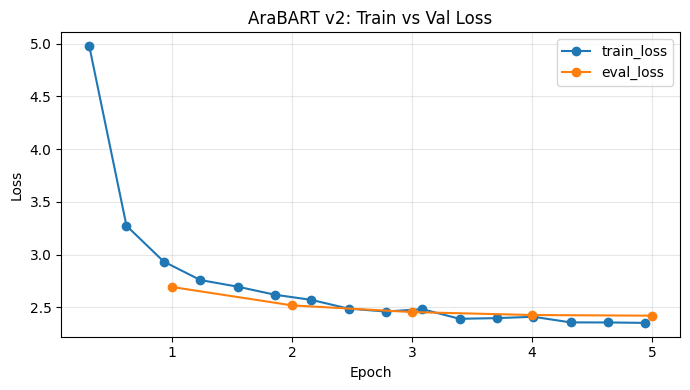

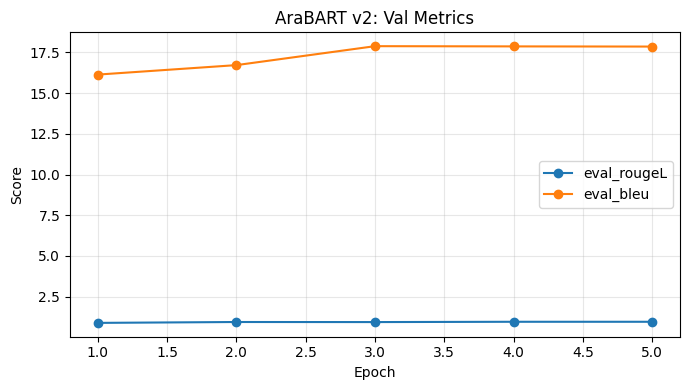

In [ ]:
import matplotlib.pyplot as plt

logs = pd.DataFrame(trainer.state.log_history)


train_loss = logs[logs.get("loss").notna()][["epoch","loss"]].groupby("epoch", as_index=False).mean()
eval_loss  = logs[logs.get("eval_loss").notna()][["epoch","eval_loss"]]

plt.figure(figsize=(7,4))
plt.plot(train_loss["epoch"], train_loss["loss"], marker="o", label="train_loss")
plt.plot(eval_loss["epoch"],  eval_loss["eval_loss"], marker="o", label="eval_loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("AraBART v2: Train vs Val Loss")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()


eval_metrics = logs[logs.get("eval_rougeL").notna()][["epoch","eval_rougeL","eval_bleu"]]

plt.figure(figsize=(7,4))
plt.plot(eval_metrics["epoch"], eval_metrics["eval_rougeL"], marker="o", label="eval_rougeL")
plt.plot(eval_metrics["epoch"], eval_metrics["eval_bleu"], marker="o", label="eval_bleu")
plt.xlabel("Epoch"); plt.ylabel("Score"); plt.title("AraBART v2: Val Metrics")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()


In [ ]:
!pip -q install transformers accelerate datasets evaluate rouge-score sacrebleu


In [ ]:
train_prepared2 = prepare_df_v2(train_df)
val_prepared2   = prepare_df_v2(val_df)
test_prepared2  = prepare_df_v2(test_df)

from datasets import Dataset
train_ds2 = Dataset.from_pandas(train_prepared2)
val_ds2   = Dataset.from_pandas(val_prepared2)
test_ds2  = Dataset.from_pandas(test_prepared2)


In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq

model2_name = "UBC-NLP/AraT5v2-base-1024"
tokenizer2 = AutoTokenizer.from_pretrained(model2_name)
model2 = AutoModelForSeq2SeqLM.from_pretrained(model2_name)

max_source_len2 = 512
max_target_len2 = 96

def tokenize_fn2(batch):
    inputs = tokenizer2(batch["source"], max_length=max_source_len2, truncation=True)

    with tokenizer2.as_target_tokenizer():
        labels = tokenizer2(batch["target"], max_length=max_target_len2, truncation=True)
    inputs["labels"] = labels["input_ids"]
    return inputs

train_tok2 = train_ds2.map(tokenize_fn2, batched=True, remove_columns=train_ds2.column_names)
val_tok2   = val_ds2.map(tokenize_fn2, batched=True, remove_columns=val_ds2.column_names)
test_tok2  = test_ds2.map(tokenize_fn2, batched=True, remove_columns=test_ds2.column_names)

data_collator2 = DataCollatorForSeq2Seq(tokenizer=tokenizer2, model=model2)
print("AraT5v2 tokenization done.")


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/2.35M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/699 [00:00<?, ?B/s]

...

Map:   0%|          | 0/2580 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4169: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/322 [00:00<?, ? examples/s]

Map:   0%|          | 0/323 [00:00<?, ? examples/s]

AraT5v2 tokenization done.


In [ ]:
import inspect
from transformers import Seq2SeqTrainingArguments

def make_seq2seq_args(**kwargs):
    sig = inspect.signature(Seq2SeqTrainingArguments.__init__)
    params = sig.parameters


    if "evaluation_strategy" not in params and "eval_strategy" in params:
        if "evaluation_strategy" in kwargs:
            kwargs["eval_strategy"] = kwargs.pop("evaluation_strategy")

    return Seq2SeqTrainingArguments(**kwargs)

out_dir2 = "./checkpoints/arat5v2_v2_clean"

training_args2 = make_seq2seq_args(
    output_dir=out_dir2,

    evaluation_strategy="epoch",
    save_strategy="epoch",

    logging_strategy="steps",
    logging_steps=50,


    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=16,

    learning_rate=5e-5,
    num_train_epochs=5,
    warmup_ratio=0.1,
    weight_decay=0.01,

    label_smoothing_factor=0.1,

    predict_with_generate=True,
    generation_max_length=max_target_len2,
    generation_num_beams=4,

    load_best_model_at_end=True,
    metric_for_best_model="rougeL",
    greater_is_better=True,

    fp16=torch.cuda.is_available(),
    report_to="none",
    save_total_limit=2,
)
print("Training args ready.")


Training args ready.


In [ ]:
import numpy as np
import evaluate

rouge2_metric = evaluate.load("rouge")
bleu2_metric  = evaluate.load("sacrebleu")

def compute_metrics2(eval_preds):
    preds, labels = eval_preds


    if isinstance(preds, tuple):
        preds = preds[0]


    if hasattr(preds, "ndim") and preds.ndim == 3:
        preds = np.argmax(preds, axis=-1)


    preds = np.array(preds, dtype=np.int64)
    preds = np.where(preds < 0, tokenizer2.pad_token_id, preds)

    labels = np.array(labels, dtype=np.int64)
    labels = np.where(labels != -100, labels, tokenizer2.pad_token_id)

    decoded_preds  = tokenizer2.batch_decode(preds, skip_special_tokens=True)
    decoded_labels = tokenizer2.batch_decode(labels, skip_special_tokens=True)

    decoded_preds  = [normalize_ar(p) for p in decoded_preds]
    decoded_labels = [normalize_ar(l) for l in decoded_labels]

    r = rouge2_metric.compute(predictions=decoded_preds, references=decoded_labels)
    b = bleu2_metric.compute(predictions=decoded_preds, references=[[x] for x in decoded_labels])

    return {
        "rouge1": r["rouge1"],
        "rouge2": r["rouge2"],
        "rougeL": r["rougeL"],
        "bleu": b["score"]
    }

print("compute_metrics2 ready ✅")


compute_metrics2 ready ✅


In [ ]:
from transformers import Seq2SeqTrainer

trainer2 = Seq2SeqTrainer(
    model=model2,
    args=training_args2,
    train_dataset=train_tok2,
    eval_dataset=val_tok2,
    tokenizer=tokenizer2,
    data_collator=data_collator2,
    compute_metrics=compute_metrics2
)

print("trainer2 ready ✅")


/tmp/ipython-input-1858034657.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer2 = Seq2SeqTrainer(


trainer2 ready ✅


In [ ]:
trainer2.train()


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Bleu
1,3.563900,2.927495,0.690206,0.467574,0.689733,12.451979
2,3.005800,2.696585,0.915691,0.821786,0.914923,18.016544
3,2.833400,2.622706,0.944349,0.863599,0.944227,20.416551
4,2.764900,2.595983,0.944366,0.866560,0.944184,20.504907
5,2.714700,2.583689,0.949722,0.872224,0.949244,20.923308


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


TrainOutput(global_step=810, training_loss=4.243270758640619, metrics={'train_runtime': 6329.8375, 'train_samples_per_second': 2.038, 'train_steps_per_second': 0.128, 'total_flos': 6759908442731520.0, 'train_loss': 4.243270758640619, 'epoch': 5.0})

In [ ]:
test_metrics2 = trainer2.evaluate(test_tok2, metric_key_prefix="test")
print(test_metrics2)


{'test_loss': 2.5919933319091797, 'test_rouge1': 0.9581420557426752, 'test_rouge2': 0.8953747490899193, 'test_rougeL': 0.9586443484276304, 'test_bleu': 19.933301351509286, 'test_runtime': 617.6999, 'test_samples_per_second': 0.523, 'test_steps_per_second': 0.523, 'epoch': 5.0}


In [ ]:
def generate_one2(article_text):
    prompt = PROMPT_V2 + str(article_text)
    inputs = tokenizer2(prompt, return_tensors="pt", truncation=True, max_length=max_source_len2).to(model2.device)

    gen_ids = model2.generate(
        **inputs,
        max_new_tokens=max_target_len2,
        num_beams=4,
        do_sample=False,
        repetition_penalty=1.3,
        no_repeat_ngram_size=4,
        length_penalty=0.9,
        early_stopping=True
    )
    return tokenizer2.decode(gen_ids[0], skip_special_tokens=True)

for i in range(5):
    print("="*60)
    print("PRED:\n", generate_one2(test_df.loc[i,"article"]))
    print("\nGOLD:\n", test_prepared2.loc[i,"target"])


PRED:
 FACTS: كيري يلتقي مسؤولين مصريين في القاهرة ANALYTICAL: كيري يلتقي المسؤولين المصريين في القاهرة يدفع إلى تداعيات مباشرة وتغيرات قريبة BREAKING: عاجل: كيري يلتقي مسئولين مصريين في القاهرة SIMPLE: كيري يلتقي مسؤولون مصريين في القاهرة

GOLD:
 FACTS: كيري يحض الحكومة المصرية علي الحوار مع المعارضة
ANALYTICAL: كيري يحض الحكومة المصرية على الحوار مع المعارضة يدفع إلى تداعيات مباشرة وتغيرات قريبة
BREAKING: عاجل: كيري يحض الحكومة المصرية على الحوار مع المعارضة
SIMPLE: كيري يحض الحكومة المصرية على الحوار مع المعارضة
PRED:
 FACTS: هدوء في شمال كردفان بعد توقف القتال ANALYTICAL: هدوء يؤدي إلى تداعيات واضحة في المشهد العام BREAKING: عاجل: هدوء يعلن تطورًا جديدًا SIMPLE: هدوء في شمالي كردفان بعد وقف القتال

GOLD:
 FACTS: 12 قتيلا في معارك الجيش السوداني والمتمردين
ANALYTICAL: 12 قتيلا في يدفع إلى 12 قتيلا في معارك ويغيّر المشهد
BREAKING: عاجل: 12 قتيلا في معارك بين الجيش السوداني ومتمردين
SIMPLE: 12 قتيلا في معارك الجيش السوداني والمتمردين
PRED:
 FACTS: اردوغان يدعو الي وقف فوري للاحتجاجات 

In [ ]:
N = 50

pred_texts2 = [generate_one2(test_df.loc[i, "article"]) for i in range(N)]
gold_texts2 = [test_prepared2.loc[i, "target"] for i in range(N)]

print("done:", len(pred_texts2), len(gold_texts2))
print("PRED sample:\n", pred_texts2[0])
print("GOLD sample:\n", gold_texts2[0])


done: 50 50
PRED sample:
 FACTS: كيري يلتقي مسؤولين مصريين في القاهرة ANALYTICAL: كيري يلتقي المسؤولين المصريين في القاهرة يدفع إلى تداعيات مباشرة وتغيرات قريبة BREAKING: عاجل: كيري يلتقي مسئولين مصريين في القاهرة SIMPLE: كيري يلتقي مسؤولون مصريين في القاهرة
GOLD sample:
 FACTS: كيري يحض الحكومة المصرية علي الحوار مع المعارضة
ANALYTICAL: كيري يحض الحكومة المصرية على الحوار مع المعارضة يدفع إلى تداعيات مباشرة وتغيرات قريبة
BREAKING: عاجل: كيري يحض الحكومة المصرية على الحوار مع المعارضة
SIMPLE: كيري يحض الحكومة المصرية على الحوار مع المعارضة


In [ ]:
import re
import numpy as np
import evaluate


rouge_m2 = evaluate.load("rouge")
bleu_m2  = evaluate.load("sacrebleu")


def parse_3styles_block(text):
    t = str(text)

    def get(label, next_labels):
        pattern = rf"{label}\s*:\s*(.*?)(?=(" + "|".join([rf"{nl}\s*:" for nl in next_labels]) + r")|$)"
        m = re.search(pattern, t, flags=re.IGNORECASE | re.DOTALL)
        return re.sub(r"\s+", " ", m.group(1)).strip() if m else ""

    return {
        "analytical": get("ANALYTICAL", ["BREAKING","SIMPLE"]),
        "breaking":   get("BREAKING",   ["SIMPLE","ANALYTICAL"]),
        "simple":     get("SIMPLE",     ["ANALYTICAL","BREAKING"]),
    }


def style_metrics_arat5v2_full(pred_texts2, gold_texts2):
    styles = ["analytical", "breaking", "simple"]
    res = {}

    P = [parse_3styles_block(t) for t in pred_texts2]
    G = [parse_3styles_block(t) for t in gold_texts2]


    print("SANITY CHECK:")
    print("PRED parsed[0]:", P[0])
    print("GOLD parsed[0]:", G[0])
    print("-"*60)

    for s in styles:
        preds = [normalize_ar(x[s]) for x in P]
        refs  = [normalize_ar(x[s]) for x in G]

        r = rouge_m2.compute(predictions=preds, references=refs)
        b = bleu_m2.compute(predictions=preds, references=[[x] for x in refs])

        res[s] = {
            "rouge1": float(r["rouge1"]),
            "rouge2": float(r["rouge2"]),
            "rougeL": float(r["rougeL"]),
            "bleu":   float(b["score"]),
        }

    res["overall"] = {
        k: float(np.mean([res[s][k] for s in styles]))
        for k in ["rouge1", "rouge2", "rougeL", "bleu"]
    }

    return res

#
results_arat5v2 = style_metrics_arat5v2_full(pred_texts2, gold_texts2)
results_arat5v2


SANITY CHECK:
PRED parsed[0]: {'analytical': 'كيري يلتقي المسؤولين المصريين في القاهرة يدفع إلى تداعيات مباشرة وتغيرات قريبة', 'breaking': 'عاجل: كيري يلتقي مسئولين مصريين في القاهرة', 'simple': 'كيري يلتقي مسؤولون مصريين في القاهرة'}
GOLD parsed[0]: {'analytical': 'كيري يحض الحكومة المصرية على الحوار مع المعارضة يدفع إلى تداعيات مباشرة وتغيرات قريبة', 'breaking': 'عاجل: كيري يحض الحكومة المصرية على الحوار مع المعارضة', 'simple': 'كيري يحض الحكومة المصرية على الحوار مع المعارضة'}
------------------------------------------------------------


{'analytical': {'rouge1': 0.0,
  'rouge2': 0.0,
  'rougeL': 0.0,
  'bleu': 15.66955942453495},
 'breaking': {'rouge1': 0.02,
  'rouge2': 0.0,
  'rougeL': 0.02,
  'bleu': 6.950720592274404},
 'simple': {'rouge1': 0.0,
  'rouge2': 0.0,
  'rougeL': 0.0,
  'bleu': 2.026707019185605},
 'overall': {'rouge1': 0.006666666666666667,
  'rouge2': 0.0,
  'rougeL': 0.006666666666666667,
  'bleu': 8.215662345331653}}

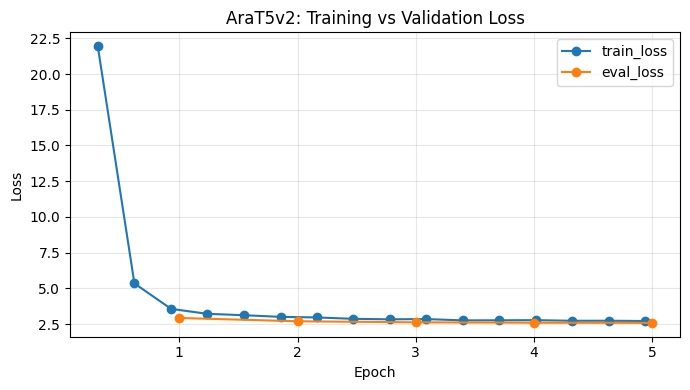

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

logs2 = pd.DataFrame(trainer2.state.log_history)


train_loss2 = logs2[logs2.get("loss").notna()][["epoch","loss"]].groupby("epoch", as_index=False).mean()
eval_loss2  = logs2[logs2.get("eval_loss").notna()][["epoch","eval_loss"]]

plt.figure(figsize=(7,4))
plt.plot(train_loss2["epoch"], train_loss2["loss"], marker="o", label="train_loss")
plt.plot(eval_loss2["epoch"],  eval_loss2["eval_loss"], marker="o", label="eval_loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("AraT5v2: Training vs Validation Loss")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()

plt.savefig("arat5v2_loss_curve.png", dpi=200)
plt.show()


In [ ]:
N = min(50, len(test_df))

pred_texts2 = [generate_one2(test_df.iloc[i]["article"]) for i in range(N)]
gold_texts2 = [test_prepared2.iloc[i]["target"] for i in range(N)]

print("done:", len(pred_texts2), len(gold_texts2))
print("PRED[0]:", pred_texts2[0])
print("GOLD[0]:", gold_texts2[0])


done: 50 50
PRED[0]: FACTS: كيري يلتقي مسؤولين مصريين في القاهرة ANALYTICAL: كيري يلتقي المسؤولين المصريين في القاهرة يدفع إلى تداعيات مباشرة وتغيرات قريبة BREAKING: عاجل: كيري يلتقي مسئولين مصريين في القاهرة SIMPLE: كيري يلتقي مسؤولون مصريين في القاهرة
GOLD[0]: FACTS: كيري يحض الحكومة المصرية علي الحوار مع المعارضة
ANALYTICAL: كيري يحض الحكومة المصرية على الحوار مع المعارضة يدفع إلى تداعيات مباشرة وتغيرات قريبة
BREAKING: عاجل: كيري يحض الحكومة المصرية على الحوار مع المعارضة
SIMPLE: كيري يحض الحكومة المصرية على الحوار مع المعارضة


In [ ]:
results_arat5v2 = style_metrics_arat5v2_full(pred_texts2, gold_texts2)
results_arat5v2


SANITY CHECK:
PRED parsed[0]: {'analytical': 'كيري يلتقي المسؤولين المصريين في القاهرة يدفع إلى تداعيات مباشرة وتغيرات قريبة', 'breaking': 'عاجل: كيري يلتقي مسئولين مصريين في القاهرة', 'simple': 'كيري يلتقي مسؤولون مصريين في القاهرة'}
GOLD parsed[0]: {'analytical': 'كيري يحض الحكومة المصرية على الحوار مع المعارضة يدفع إلى تداعيات مباشرة وتغيرات قريبة', 'breaking': 'عاجل: كيري يحض الحكومة المصرية على الحوار مع المعارضة', 'simple': 'كيري يحض الحكومة المصرية على الحوار مع المعارضة'}
------------------------------------------------------------


{'analytical': {'rouge1': 0.0,
  'rouge2': 0.0,
  'rougeL': 0.0,
  'bleu': 15.66955942453495},
 'breaking': {'rouge1': 0.02,
  'rouge2': 0.0,
  'rougeL': 0.02,
  'bleu': 6.950720592274404},
 'simple': {'rouge1': 0.0,
  'rouge2': 0.0,
  'rougeL': 0.0,
  'bleu': 2.026707019185605},
 'overall': {'rouge1': 0.006666666666666667,
  'rouge2': 0.0,
  'rougeL': 0.006666666666666667,
  'bleu': 8.215662345331653}}

In [ ]:
print(test_df.iloc[0]["article"][:200])
print("----")
print(test_prepared2.iloc[0]["target"])


والتقى كيري أيضا وزير الدفاع المصري، عبد الفتاح السيسي، وتباحث معه سبل التعاون العسكري بين مصر والولايات المتحدة الأمريكية. وتناول وزير الخارجية الأمريكي مع المسؤولين المصريين الوضع الاقتصادي في مصر، 
----
FACTS: كيري يحض الحكومة المصرية علي الحوار مع المعارضة
ANALYTICAL: كيري يحض الحكومة المصرية على الحوار مع المعارضة يدفع إلى تداعيات مباشرة وتغيرات قريبة
BREAKING: عاجل: كيري يحض الحكومة المصرية على الحوار مع المعارضة
SIMPLE: كيري يحض الحكومة المصرية على الحوار مع المعارضة


In [ ]:
!pip -q install bert-score sentence-transformers


In [ ]:
import re

def parse_3styles_block(text):
    t = str(text)

    def get(label, next_labels):
        pattern = rf"{label}\s*:\s*(.*?)(?=(" + "|".join([rf"{nl}\s*:" for nl in next_labels]) + r")|$)"
        m = re.search(pattern, t, flags=re.IGNORECASE | re.DOTALL)
        return re.sub(r"\s+", " ", m.group(1)).strip() if m else ""

    return {
        "analytical": get("ANALYTICAL", ["BREAKING","SIMPLE"]),
        "breaking":   get("BREAKING",   ["SIMPLE","ANALYTICAL"]),
        "simple":     get("SIMPLE",     ["ANALYTICAL","BREAKING"]),
    }


In [ ]:
styles = ["analytical", "breaking", "simple"]

P2 = [parse_3styles_block(t) for t in pred_texts2]
G2 = [parse_3styles_block(t) for t in gold_texts2]

pred_by_style2 = {s: [normalize_ar(x[s]) for x in P2] for s in styles}
gold_by_style2 = {s: [normalize_ar(x[s]) for x in G2] for s in styles}

# sanity
print(pred_by_style2["breaking"][0])
print(gold_by_style2["breaking"][0])


عاجل: كيري يلتقي مسئولين مصريين في القاهرة
عاجل: كيري يحض الحكومة المصرية علي الحوار مع المعارضة


In [ ]:
from bert_score import score

def bertscore_per_style(pred_by_style, gold_by_style, model_type="bert-base-multilingual-cased"):
    out = {}
    for s in ["analytical","breaking","simple"]:
        P, R, F1 = score(pred_by_style[s], gold_by_style[s], lang="ar", model_type=model_type, verbose=False)
        out[s] = {
            "BERTScore_P": float(P.mean()),
            "BERTScore_R": float(R.mean()),
            "BERTScore_F1": float(F1.mean())
        }

    out["overall"] = {
        "BERTScore_F1": float(sum(out[s]["BERTScore_F1"] for s in ["analytical","breaking","simple"]) / 3.0)
    }
    return out

bertscore_arat5v2 = bertscore_per_style(pred_by_style2, gold_by_style2)
bertscore_arat5v2


{'analytical': {'BERTScore_P': 0.7619032263755798,
  'BERTScore_R': 0.7529293298721313,
  'BERTScore_F1': 0.7570334076881409},
 'breaking': {'BERTScore_P': 0.7986007928848267,
  'BERTScore_R': 0.7765559554100037,
  'BERTScore_F1': 0.7870224118232727},
 'simple': {'BERTScore_P': 0.7341935634613037,
  'BERTScore_R': 0.725344181060791,
  'BERTScore_F1': 0.7294580340385437},
 'overall': {'BERTScore_F1': 0.7578379511833191}}

In [ ]:
from bert_score import score

def bertscore_per_style(pred_by_style, gold_by_style, model_type="bert-base-multilingual-cased"):
    out = {}
    for s in ["analytical","breaking","simple"]:
        P, R, F1 = score(pred_by_style[s], gold_by_style[s], lang="ar", model_type=model_type, verbose=False)
        out[s] = {
            "BERTScore_P": float(P.mean()),
            "BERTScore_R": float(R.mean()),
            "BERTScore_F1": float(F1.mean())
        }

    out["overall"] = {
        "BERTScore_F1": float(sum(out[s]["BERTScore_F1"] for s in ["analytical","breaking","simple"]) / 3.0)
    }
    return out

bertscore_arat5v2 = bertscore_per_style(pred_by_style2, gold_by_style2)
bertscore_arat5v2


{'analytical': {'BERTScore_P': 0.7619032263755798,
  'BERTScore_R': 0.7529293298721313,
  'BERTScore_F1': 0.7570334076881409},
 'breaking': {'BERTScore_P': 0.7986007928848267,
  'BERTScore_R': 0.7765559554100037,
  'BERTScore_F1': 0.7870224118232727},
 'simple': {'BERTScore_P': 0.7341935634613037,
  'BERTScore_R': 0.725344181060791,
  'BERTScore_F1': 0.7294580340385437},
 'overall': {'BERTScore_F1': 0.7578379511833191}}

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np

embedder = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

def cosine_sim(a, b):
    # a,b: numpy arrays
    a = a / (np.linalg.norm(a, axis=1, keepdims=True) + 1e-12)
    b = b / (np.linalg.norm(b, axis=1, keepdims=True) + 1e-12)
    return (a * b).sum(axis=1)

def cosine_per_style(pred_by_style, gold_by_style):
    out = {}
    for s in ["analytical","breaking","simple"]:
        emb_p = embedder.encode(pred_by_style[s], convert_to_numpy=True, show_progress_bar=False)
        emb_g = embedder.encode(gold_by_style[s], convert_to_numpy=True, show_progress_bar=False)
        sims = cosine_sim(emb_p, emb_g)
        out[s] = {"cosine_sim": float(np.mean(sims))}
    out["overall"] = {"cosine_sim": float(np.mean([out[s]["cosine_sim"] for s in ["analytical","breaking","simple"]]))}
    return out

cosine_arat5v2 = cosine_per_style(pred_by_style2, gold_by_style2)
cosine_arat5v2


{'analytical': {'cosine_sim': 0.5630606412887573},
 'breaking': {'cosine_sim': 0.6590031385421753},
 'simple': {'cosine_sim': 0.5888559818267822},
 'overall': {'cosine_sim': 0.6036399205525717}}

In [ ]:
import pandas as pd

rows = []
for s in ["analytical","breaking","simple","overall"]:
    rows.append({
        "style": s,
        "AraBART_ROUGE-L": results_arabart[s]["rougeL"],
        "AraBART_BLEU": results_arabart[s]["bleu"],
        "AraBART_BERT_F1": bertscore_arabart_res[s]["BERTScore_F1"] if s!="overall" else bertscore_arabart_res["overall"]["BERTScore_F1"],
        "AraBART_Cosine": cosine_arabart_res[s]["cosine_sim"] if s!="overall" else cosine_arabart_res["overall"]["cosine_sim"],

        "AraT5v2_ROUGE-L": results_arat5v2[s]["rougeL"],
        "AraT5v2_BLEU": results_arat5v2[s]["bleu"],
        "AraT5v2_BERT_F1": bertscore_arat5v2[s]["BERTScore_F1"] if s!="overall" else bertscore_arat5v2["overall"]["BERTScore_F1"],
        "AraT5v2_Cosine": cosine_arat5v2[s]["cosine_sim"] if s!="overall" else cosine_arat5v2["overall"]["cosine_sim"],
    })

compare_df = pd.DataFrame(rows)
compare_df


,style,AraBART_ROUGE-L,AraBART_BLEU,AraBART_BERT_F1,AraBART_Cosine,AraT5v2_ROUGE-L,AraT5v2_BLEU,AraT5v2_BERT_F1,AraT5v2_Cosine
0,analytical,0.0,18.836262,0.776238,0.610688,0.000000,15.669559,0.757033,0.563061
1,breaking,0.0,8.524070,0.792651,0.660044,0.020000,6.950721,0.787022,0.659003
2,simple,0.0,1.663255,0.720632,0.569317,0.000000,2.026707,0.729458,0.588856
3,overall,0.0,9.674529,0.763174,0.613350,0.006667,8.215662,0.757838,0.603640


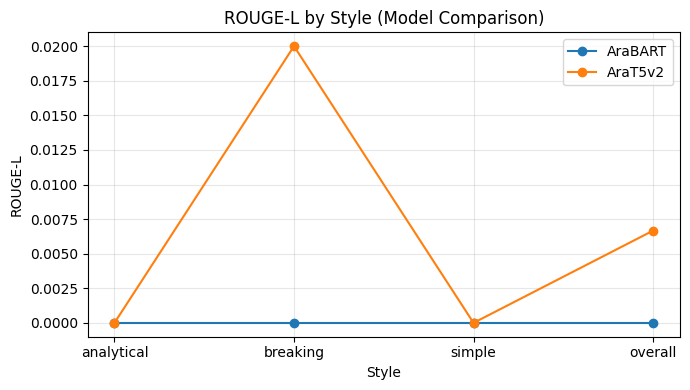

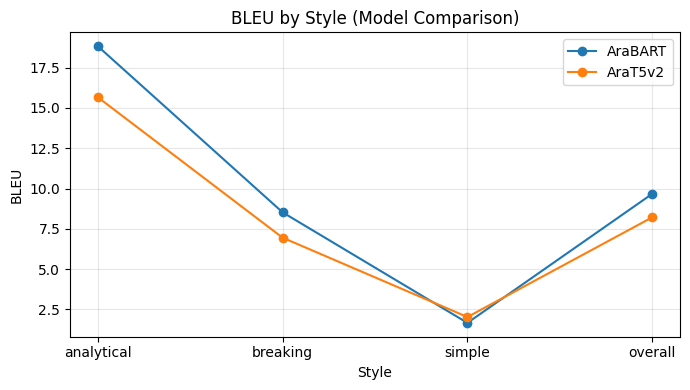

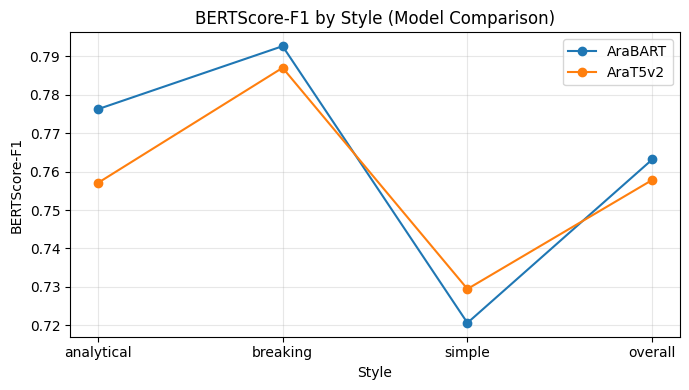

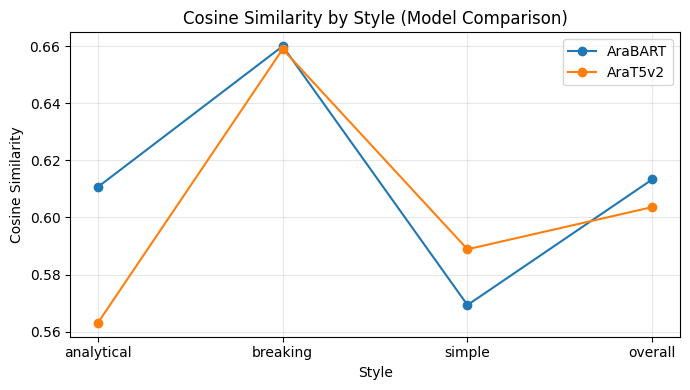

Saved plots: compare_rougeL.png, compare_bleu.png, compare_bertscore_f1.png, compare_cosine.png


In [ ]:
import matplotlib.pyplot as plt

styles = ["analytical","breaking","simple","overall"]
dfp = compare_df.set_index("style").loc[styles]

# 1) ROUGE-L comparison
plt.figure(figsize=(7,4))
plt.plot(dfp.index, dfp["AraBART_ROUGE-L"], marker="o", label="AraBART")
plt.plot(dfp.index, dfp["AraT5v2_ROUGE-L"], marker="o", label="AraT5v2")
plt.title("ROUGE-L by Style (Model Comparison)")
plt.xlabel("Style"); plt.ylabel("ROUGE-L")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
plt.savefig("compare_rougeL.png", dpi=200)
plt.show()

# 2) BLEU comparison
plt.figure(figsize=(7,4))
plt.plot(dfp.index, dfp["AraBART_BLEU"], marker="o", label="AraBART")
plt.plot(dfp.index, dfp["AraT5v2_BLEU"], marker="o", label="AraT5v2")
plt.title("BLEU by Style (Model Comparison)")
plt.xlabel("Style"); plt.ylabel("BLEU")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
plt.savefig("compare_bleu.png", dpi=200)
plt.show()

# 3) BERTScore F1 comparison
plt.figure(figsize=(7,4))
plt.plot(dfp.index, dfp["AraBART_BERT_F1"], marker="o", label="AraBART")
plt.plot(dfp.index, dfp["AraT5v2_BERT_F1"], marker="o", label="AraT5v2")
plt.title("BERTScore-F1 by Style (Model Comparison)")
plt.xlabel("Style"); plt.ylabel("BERTScore-F1")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
plt.savefig("compare_bertscore_f1.png", dpi=200)
plt.show()

# 4) Cosine similarity comparison
plt.figure(figsize=(7,4))
plt.plot(dfp.index, dfp["AraBART_Cosine"], marker="o", label="AraBART")
plt.plot(dfp.index, dfp["AraT5v2_Cosine"], marker="o", label="AraT5v2")
plt.title("Cosine Similarity by Style (Model Comparison)")
plt.xlabel("Style"); plt.ylabel("Cosine Similarity")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
plt.savefig("compare_cosine.png", dpi=200)
plt.show()

print("Saved plots:",
      "compare_rougeL.png, compare_bleu.png, compare_bertscore_f1.png, compare_cosine.png")


#mt5

In [ ]:
# Reuse your existing prepared datasets
train_prepared3 = prepare_df_v2(train_df)
val_prepared3   = prepare_df_v2(val_df)
test_prepared3  = prepare_df_v2(test_df)

from datasets import Dataset

train_ds3 = Dataset.from_pandas(train_prepared3)
val_ds3   = Dataset.from_pandas(val_prepared3)
test_ds3  = Dataset.from_pandas(test_prepared3)

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq

model3_name = "google/mt5-small"
tokenizer3 = AutoTokenizer.from_pretrained(model3_name)
model3 = AutoModelForSeq2SeqLM.from_pretrained(model3_name)

print(f"Model loaded: {model3_name}")
print(f"Number of parameters: {model3.num_parameters():,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
/usr/local/lib/pytho

Model loaded: google/mt5-small
Number of parameters: 300,176,768


In [ ]:
max_source_len = 512
max_target_len = 96

def tokenize_fn3(batch):
    inputs = tokenizer3(batch["source"], max_length=max_source_len, truncation=True)
    labels = tokenizer3(batch["target"], max_length=max_target_len, truncation=True)
    inputs["labels"] = labels["input_ids"]
    return inputs

train_tok3 = train_ds3.map(tokenize_fn3, batched=True, remove_columns=train_ds3.column_names)
val_tok3   = val_ds3.map(tokenize_fn3, batched=True, remove_columns=val_ds3.column_names)
test_tok3  = test_ds3.map(tokenize_fn3, batched=True, remove_columns=test_ds3.column_names)

data_collator3 = DataCollatorForSeq2Seq(tokenizer3, model=model3)

Map:   0%|          | 0/2580 [00:00<?, ? examples/s]

Map:   0%|          | 0/322 [00:00<?, ? examples/s]

Map:   0%|          | 0/323 [00:00<?, ? examples/s]

In [ ]:
import numpy as np
import evaluate

rouge3_metric = evaluate.load("rouge")
bleu3_metric  = evaluate.load("sacrebleu")

def compute_metrics3(eval_preds):
    preds, labels = eval_preds

    # Decode predictions
    if isinstance(preds, tuple):
        preds = preds[0]

    # Replace -100 in labels
    labels = np.where(labels != -100, labels, tokenizer3.pad_token_id)

    decoded_preds = tokenizer3.batch_decode(preds, skip_special_tokens=True)
    decoded_labels = tokenizer3.batch_decode(labels, skip_special_tokens=True)

    # Compute ROUGE
    rouge_result = rouge3_metric.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=False
    )

    # Compute BLEU
    bleu_result = bleu3_metric.compute(
        predictions=decoded_preds,
        references=[[ref] for ref in decoded_labels]
    )

    return {
        "rouge1": rouge_result["rouge1"],
        "rouge2": rouge_result["rouge2"],
        "rougeL": rouge_result["rougeL"],
        "bleu": bleu_result["score"]
    }

In [ ]:
from transformers import Seq2SeqTrainingArguments

out_dir3 = "./checkpoints/mt5_small_v2_clean"

training_args3 = Seq2SeqTrainingArguments(
    output_dir=out_dir3,

    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=8,
    weight_decay=0.01,
    save_total_limit=2,
    num_train_epochs=5,
    predict_with_generate=True,
    generation_max_length=max_target_len,
    generation_num_beams=4,

    fp16=False,
    logging_dir=f"{out_dir3}/logs",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="rougeL",
    greater_is_better=True,
    report_to="none",
    push_to_hub=False,
     max_grad_norm=1.0,  # Gradient clipping
    warmup_steps=100,
)



In [ ]:
from transformers import Seq2SeqTrainer

trainer3 = Seq2SeqTrainer(
    model=model3,
    args=training_args3,
    train_dataset=train_tok3,
    eval_dataset=val_tok3,
    tokenizer=tokenizer3,
    data_collator=data_collator3,
    compute_metrics=compute_metrics3,
)

print("Starting training for mT5-small...")
trainer3.train()

/tmp/ipython-input-2379179744.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer3 = Seq2SeqTrainer(


Starting training for mT5-small...


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Bleu
1,9.924600,3.451768,0.080354,0.007743,0.080163,0.288491
2,4.049900,2.204370,0.219801,0.040680,0.219368,1.254920
3,3.263400,1.943434,0.242707,0.007892,0.242144,1.182900
4,2.975000,1.830950,0.238015,0.003143,0.238204,1.352980
5,2.868100,1.798261,0.244154,0.004361,0.243992,1.556691


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


TrainOutput(global_step=810, training_loss=5.900736886483652, metrics={'train_runtime': 2906.3641, 'train_samples_per_second': 4.439, 'train_steps_per_second': 0.279, 'total_flos': 5919957959946240.0, 'train_loss': 5.900736886483652, 'epoch': 5.0})

In [ ]:
test_metrics3 = trainer3.evaluate(test_tok3, metric_key_prefix="test")
print(test_metrics3)

{'test_loss': 1.8137859106063843, 'test_rouge1': 0.24565471631879335, 'test_rouge2': 0.0026413215267704435, 'test_rougeL': 0.2455909138770567, 'test_bleu': 1.6295309880130733, 'test_runtime': 165.7899, 'test_samples_per_second': 1.948, 'test_steps_per_second': 0.489, 'epoch': 5.0}


In [ ]:
def generate_one3(article_text):
    prompt = PROMPT_V2 + str(article_text)
    inputs = tokenizer3(prompt, return_tensors="pt", truncation=True, max_length=512).to(model3.device)

    outputs = model3.generate(
        **inputs,
        max_length=96,
        num_beams=4,
        early_stopping=True,
        no_repeat_ngram_size=2
    )

    return tokenizer3.decode(outputs[0], skip_special_tokens=True)

# Test on first few examples
for i in range(3):
    print("="*60)
    pred = generate_one3(test_df.loc[i, "article"])
    print("PRED:\n", pred)
    print("\nGOLD:\n", test_prepared3.loc[i, "target"])
    print()

PRED:
 <extra_id_0> FACTS: وزير الدفاع المصري يؤدي إلى تداعيات مباشرة ANALYTICAL: مصر

GOLD:
 FACTS: كيري يحض الحكومة المصرية علي الحوار مع المعارضة
ANALYTICAL: كيري يحض الحكومة المصرية على الحوار مع المعارضة يدفع إلى تداعيات مباشرة وتغيرات قريبة
BREAKING: عاجل: كيري يحض الحكومة المصرية على الحوار مع المعارضة
SIMPLE: كيري يحض الحكومة المصرية على الحوار مع المعارضة

PRED:
 <extra_id_0> FACTS: متمردون في السودان يدفع إلى تداعيات مباشرة ANALYTICAL: عيان يعتذر على منطقة أم روابة

GOLD:
 FACTS: 12 قتيلا في معارك الجيش السوداني والمتمردين
ANALYTICAL: 12 قتيلا في يدفع إلى 12 قتيلا في معارك ويغيّر المشهد
BREAKING: عاجل: 12 قتيلا في معارك بين الجيش السوداني ومتمردين
SIMPLE: 12 قتيلا في معارك الجيش السوداني والمتمردين

PRED:
 <extra_id_0> FACTS: أردوغان يؤدي إلى تداعيات واضحة ANALYTICAL: عاجل: حزب رئيس الوزراء BREAKING: الأردوغ يعتزم تطورًا SIMPLE: آردوغي يفتقد إليها الاحتجاجات SIMPLIC: اردوغا يضغط على ميدان تقسيم في تركيا

GOLD:
 FACTS: الاف المحتجين يتحدون اردوغان في شوارع
ANALYTICAL: آلاف يؤث

In [ ]:
N = 50

pred_texts3 = [generate_one3(test_df.loc[i, "article"]) for i in range(N)]
gold_texts3 = [test_prepared3.loc[i, "target"] for i in range(N)]

print(f"Generated {len(pred_texts3)} predictions")
print("\nExample prediction:")
print(pred_texts3[0])

Generated 50 predictions

Example prediction:
<extra_id_0> FACTS: وزير الدفاع المصري يؤدي إلى تداعيات مباشرة ANALYTICAL: مصر


In [ ]:
import re
import numpy as np
import evaluate

rouge_m3 = evaluate.load("rouge")
bleu_m3 = evaluate.load("sacrebleu")

def normalize_ar(text):
    if not isinstance(text, str):
        return ""
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)
    return text

def parse_3styles_block(text):
    t = str(text)

    def get(label, next_labels):
        pattern = rf"{label}\s*:\s*(.*?)(?=(" + "|".join([rf"{nl}\s*:" for nl in next_labels]) + r")|$)"
        match = re.search(pattern, t, re.DOTALL | re.IGNORECASE)
        if match:
            return match.group(1).strip()
        return ""

    analytical = get("Analytical", ["Breaking", "Simple"])
    breaking = get("Breaking", ["Simple", "Analytical"])
    simple = get("Simple", ["Analytical", "Breaking"])

    if not analytical:
        analytical = get("تحليلي", ["عاجل", "بسيط"])
    if not breaking:
        breaking = get("عاجل", ["بسيط", "تحليلي"])
    if not simple:
        simple = get("بسيط", ["تحليلي", "عاجل"])

    return {"analytical": analytical, "breaking": breaking, "simple": simple}

def style_metrics_mt5(pred_texts, gold_texts):
    P = [parse_3styles_block(t) for t in pred_texts]
    G = [parse_3styles_block(t) for t in gold_texts]

    results = {}

    for style in ["analytical", "breaking", "simple"]:
        preds = [normalize_ar(x[style]) for x in P]
        golds = [normalize_ar(x[style]) for x in G]
        valid_pairs = [(p, g) for p, g in zip(preds, golds) if p and g]

        if len(valid_pairs) == 0:
            results[style] = {"rougeL": 0.0, "rouge1": 0.0, "rouge2": 0.0, "bleu": 0.0}
            continue

        preds_valid = [p for p, g in valid_pairs]
        golds_valid = [g for p, g in valid_pairs]

        rouge_result = rouge_m3.compute(predictions=preds_valid, references=golds_valid, use_stemmer=False)
        bleu_result = bleu_m3.compute(predictions=preds_valid, references=[[g] for g in golds_valid])

        results[style] = {
            "rougeL": rouge_result["rougeL"],
            "rouge1": rouge_result["rouge1"],
            "rouge2": rouge_result["rouge2"],
            "bleu": bleu_result["score"] / 100.0
        }

    # Overall
    all_preds = []
    all_golds = []
    for style in ["analytical", "breaking", "simple"]:
        all_preds.extend([normalize_ar(x[style]) for x in P])
        all_golds.extend([normalize_ar(x[style]) for x in G])

    valid_pairs = [(p, g) for p, g in zip(all_preds, all_golds) if p and g]
    preds_valid = [p for p, g in valid_pairs]
    golds_valid = [g for p, g in valid_pairs]

    if len(valid_pairs) > 0:
        rouge_overall = rouge_m3.compute(predictions=preds_valid, references=golds_valid, use_stemmer=False)
        bleu_overall = bleu_m3.compute(predictions=preds_valid, references=[[g] for g in golds_valid])
        results["overall"] = {
            "rougeL": rouge_overall["rougeL"],
            "rouge1": rouge_overall["rouge1"],
            "rouge2": rouge_overall["rouge2"],
            "bleu": bleu_overall["score"] / 100.0
        }
    else:
        results["overall"] = {"rougeL": 0.0, "rouge1": 0.0, "rouge2": 0.0, "bleu": 0.0}

    return results

results_mt5 = style_metrics_mt5(pred_texts3, gold_texts3)
print("mT5 ROUGE & BLEU Results:")
for style in ["analytical", "breaking", "simple", "overall"]:
    print(f"{style}: ROUGE-L={results_mt5[style]['rougeL']:.4f}, BLEU={results_mt5[style]['bleu']:.4f}")

mT5 ROUGE & BLEU Results:
analytical: ROUGE-L=0.0000, BLEU=0.0040
breaking: ROUGE-L=0.0000, BLEU=0.0114
simple: ROUGE-L=0.0000, BLEU=0.0060
overall: ROUGE-L=0.0000, BLEU=0.0046


In [ ]:
P3 = [parse_3styles_block(t) for t in pred_texts3]
G3 = [parse_3styles_block(t) for t in gold_texts3]

pred_by_style3 = {s: [normalize_ar(x[s]) for x in P3] for s in ["analytical", "breaking", "simple"]}
gold_by_style3 = {s: [normalize_ar(x[s]) for x in G3] for s in ["analytical", "breaking", "simple"]}

print(f"Parsed {len(P3)} predictions into 3 styles")

Parsed 50 predictions into 3 styles


In [ ]:
from bert_score import score

def bertscore_per_style_mt5(pred_by_style, gold_by_style):
    out = {}
    for s in ["analytical", "breaking", "simple"]:
        preds = pred_by_style[s]
        golds = gold_by_style[s]
        valid_pairs = [(p, g) for p, g in zip(preds, golds) if p and g]

        if len(valid_pairs) == 0:
            out[s] = {"precision": 0.0, "recall": 0.0, "f1": 0.0}
            continue

        preds_valid = [p for p, g in valid_pairs]
        golds_valid = [g for p, g in valid_pairs]
        P, R, F1 = score(preds_valid, golds_valid, lang="ar", model_type="bert-base-multilingual-cased", verbose=False)
        out[s] = {"precision": P.mean().item(), "recall": R.mean().item(), "f1": F1.mean().item()}

    # Overall
    all_preds = []
    all_golds = []
    for s in ["analytical", "breaking", "simple"]:
        all_preds.extend(pred_by_style[s])
        all_golds.extend(gold_by_style[s])

    valid_pairs = [(p, g) for p, g in zip(all_preds, all_golds) if p and g]
    if len(valid_pairs) > 0:
        preds_valid = [p for p, g in valid_pairs]
        golds_valid = [g for p, g in valid_pairs]
        P, R, F1 = score(preds_valid, golds_valid, lang="ar", model_type="bert-base-multilingual-cased", verbose=False)
        out["overall"] = {"precision": P.mean().item(), "recall": R.mean().item(), "f1": F1.mean().item()}
    else:
        out["overall"] = {"precision": 0.0, "recall": 0.0, "f1": 0.0}

    return out

bertscore_mt5 = bertscore_per_style_mt5(pred_by_style3, gold_by_style3)
print("mT5 BERTScore Results:")
for style, scores in bertscore_mt5.items():
    print(f"{style}: F1={scores['f1']:.4f}")

mT5 BERTScore Results:
analytical: F1=0.6822
breaking: F1=0.7008
simple: F1=0.6787
overall: F1=0.6877


In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np

try:
    embedder
except:
    embedder = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def cosine_per_style_mt5(pred_by_style, gold_by_style):
    out = {}
    for s in ["analytical", "breaking", "simple"]:
        preds = pred_by_style[s]
        golds = gold_by_style[s]
        valid_pairs = [(p, g) for p, g in zip(preds, golds) if p and g]

        if len(valid_pairs) == 0:
            out[s] = 0.0
            continue

        preds_valid = [p for p, g in valid_pairs]
        golds_valid = [g for p, g in valid_pairs]
        emb_pred = embedder.encode(preds_valid)
        emb_gold = embedder.encode(golds_valid)
        sims = [cosine_sim(p, g) for p, g in zip(emb_pred, emb_gold)]
        out[s] = np.mean(sims)

    # Overall
    all_preds = []
    all_golds = []
    for s in ["analytical", "breaking", "simple"]:
        all_preds.extend(pred_by_style[s])
        all_golds.extend(gold_by_style[s])

    valid_pairs = [(p, g) for p, g in zip(all_preds, all_golds) if p and g]
    if len(valid_pairs) > 0:
        preds_valid = [p for p, g in valid_pairs]
        golds_valid = [g for p, g in valid_pairs]
        emb_pred = embedder.encode(preds_valid)
        emb_gold = embedder.encode(golds_valid)
        sims = [cosine_sim(p, g) for p, g in zip(emb_pred, emb_gold)]
        out["overall"] = np.mean(sims)
    else:
        out["overall"] = 0.0

    return out

cosine_mt5 = cosine_per_style_mt5(pred_by_style3, gold_by_style3)
print("mT5 Cosine Similarity Results:")
for style, score_val in cosine_mt5.items():
    print(f"{style}: {score_val:.4f}")

mT5 Cosine Similarity Results:
analytical: 0.3983
breaking: 0.4988
simple: 0.3606
overall: 0.4239


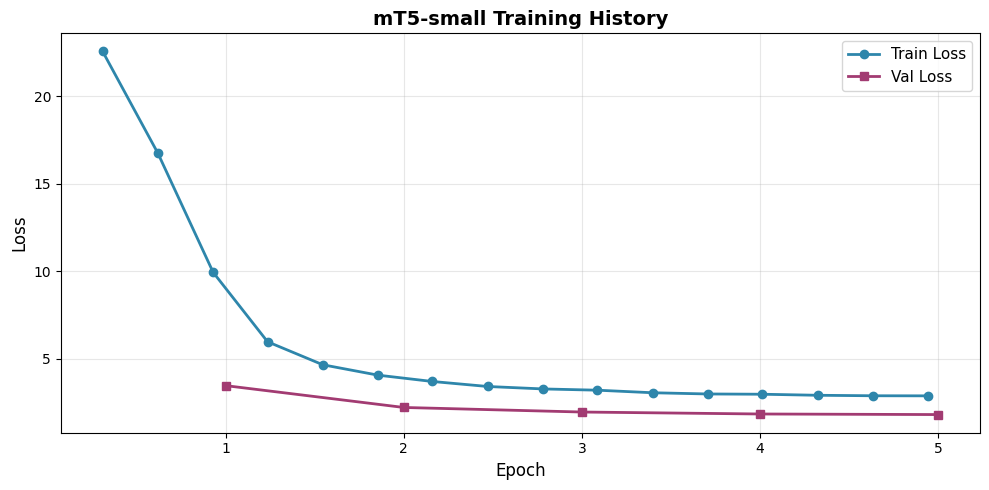

Saved: mt5_training_history.png


In [ ]:
!zip -r checkpoints.zip /content/checkpoints


  adding: content/checkpoints/ (stored 0%)
  adding: content/checkpoints/mt5_small_v2_clean/ (stored 0%)
  adding: content/checkpoints/mt5_small_v2_clean/checkpoint-648/ (stored 0%)
  adding: content/checkpoints/mt5_small_v2_clean/checkpoint-648/model.safetensors (deflated 26%)
  adding: content/checkpoints/mt5_small_v2_clean/checkpoint-648/scheduler.pt (deflated 61%)
  adding: content/checkpoints/mt5_small_v2_clean/checkpoint-648/spiece.model (deflated 46%)
  adding: content/checkpoints/mt5_small_v2_clean/checkpoint-648/trainer_state.json (deflated 69%)
  adding: content/checkpoints/mt5_small_v2_clean/checkpoint-648/rng_state.pth (deflated 26%)
  adding: content/checkpoints/mt5_small_v2_clean/checkpoint-648/tokenizer.json (deflated 76%)
  adding: content/checkpoints/mt5_small_v2_clean/checkpoint-648/config.json (deflated 47%)
  adding: content/checkpoints/mt5_small_v2_clean/checkpoint-648/special_tokens_map.json (deflated 73%)
  adding: content/checkpoints/mt5_small_v2_clean/checkpoin

In [ ]:
!rm -f checkpoints.zip checkpoints.z*
!zip -r -s 1900m checkpoints.zip checkpoints
!ls -lh checkpoints.z* checkpoints.zip


  adding: checkpoints/ (stored 0%)
  adding: checkpoints/mt5_small_v2_clean/ (stored 0%)
  adding: checkpoints/mt5_small_v2_clean/checkpoint-648/ (stored 0%)
  adding: checkpoints/mt5_small_v2_clean/checkpoint-648/model.safetensors (deflated 26%)
  adding: checkpoints/mt5_small_v2_clean/checkpoint-648/scheduler.pt (deflated 61%)
  adding: checkpoints/mt5_small_v2_clean/checkpoint-648/spiece.model (deflated 46%)
  adding: checkpoints/mt5_small_v2_clean/checkpoint-648/trainer_state.json (deflated 69%)
  adding: checkpoints/mt5_small_v2_clean/checkpoint-648/rng_state.pth (deflated 26%)
  adding: checkpoints/mt5_small_v2_clean/checkpoint-648/tokenizer.json (deflated 76%)
  adding: checkpoints/mt5_small_v2_clean/checkpoint-648/config.json (deflated 47%)
  adding: checkpoints/mt5_small_v2_clean/checkpoint-648/special_tokens_map.json (deflated 73%)
  adding: checkpoints/mt5_small_v2_clean/checkpoint-648/tokenizer_config.json (deflated 95%)
  adding: checkpoints/mt5_small_v2_clean/checkpoint-6

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!mkdir -p "/content/drive/MyDrive/checkpoints_parts"
!cp checkpoints.z* checkpoints.zip "/content/drive/MyDrive/checkpoints_parts/"
!ls -lh "/content/drive/MyDrive/checkpoints_parts"


cp: cannot stat 'checkpoints.z*': No such file or directory
cp: cannot stat 'checkpoints.zip': No such file or directory
total 4.5G
-rw------- 1 root root 1.9G Jan  3 11:08 checkpoints.z01
-rw------- 1 root root 1.9G Jan  3 11:09 checkpoints.z02
-rw------- 1 root root 746M Jan  3 11:09 checkpoints.z03


#all models